# Disease Mapping using MCMC

The notebook demonstrates how MCMC can be used to estimate true disease rates across spatially correlated counties, smoothing random noise while preserving real disease clusters.


In [83]:
"""
PyMC is great for Bayesian statistical modeling (focusing on full posterior distributions and uncertainty quantification)
"""

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pymc as pm
import pytensor
import os
from matplotlib.patches import Rectangle

# Configure PyTensor BEFORE importing PyMC to avoid C compilation issues on macOS
os.environ['PYTENSOR_FLAGS'] = 'device=cpu,floatX=float64,optimizer=None,cxx='
pytensor.config.floatX = 'float64'
pytensor.config.compute_test_value = 'off'

# Set random seed for reproducibility
np.random.seed(42)

%matplotlib inline
plt.style.use('default')

## 1. The Data Model

### Observed Cases

For county $(i,j)$ with population $N_{ij}$ and true disease rate $\theta_{ij}$ (per 10,000):

**Expected number of cases:**
$$
\lambda_{ij} = \frac{\theta_{ij}}{10000} \times N_{ij}
$$

Observed cases follow a **Poisson distribution**:
$$
y_{ij} \sim \text{Poisson}(\lambda_{ij})
$$

This means:
$$
P(y_{ij} | \theta_{ij}, N_{ij}) = \frac{\lambda_{ij}^{y_{ij}} e^{-\lambda_{ij}}}{y_{ij}!}
$$

In [84]:
def create_county_grid(grid_size=5):
    """
    Create a grid of counties with true underlying disease rates.
    
    We'll create a spatial pattern with:
    - A disease cluster in the lower-right corner
    - Lower baseline rates elsewhere
    - Smooth spatial variation
    """
    counties = np.zeros((grid_size, grid_size))
    
    for i in range(grid_size):
        for j in range(grid_size):
            # Base rate
            base_rate = 12
            
            # Create a cluster in lower-right corner (high i, high j)
            # i=4, j=4 should be the center of the cluster
            cluster_effect = 8 * np.exp(-((i-4)**2 + (j-4)**2) / 2)
            
            # Add smooth spatial gradient (increases toward lower-right)
            gradient = (i + j) * 0.5
            
            counties[i, j] = base_rate + cluster_effect + gradient
    
    return counties

In [85]:
def generate_observed_cases(true_rates, population_sizes):
    """
    Generate observed case counts based on true rates and population sizes.
    Uses Poisson distribution to add random variation.
    
    Small counties will have more relative variation / noise.
    """
    observed = np.zeros_like(true_rates)
    
    for i in range(true_rates.shape[0]):
        for j in range(true_rates.shape[1]):
            # Expected number of cases
            expected_cases = (true_rates[i, j] / 10000) * population_sizes[i, j]
            
            # Generate random observation (Poisson noise)
            actual_cases = np.random.poisson(expected_cases)
            
            # Convert back to rate per 10,000
            observed[i, j] = (actual_cases / population_sizes[i, j]) * 10000
    
    return observed

## 2. The Likelihood Function

### Log-Likelihood

Taking logarithms (easier to compute):
$$
\log \mathcal{L}(\boldsymbol{\theta} | \mathbf{y}) = \sum_{i=1}^{n} \sum_{j=1}^{n} \left[ y_{ij} \log(\lambda_{ij}) - \lambda_{ij} - \log(y_{ij}!) \right]
$$

In [86]:
def log_likelihood(observed, estimated, population_sizes):
    """
    Calculate log-likelihood of observed data given estimated rates.
    
    Uses PyMC's Poisson distribution for log probability calculation.
    """
    from scipy.special import loggamma
    
    # Convert rates to expected counts
    expected_counts = (estimated / 10000) * population_sizes
    actual_counts = np.round((observed / 10000) * population_sizes).astype(int)
    
    # Compute Poisson log PMF: log(P(k)) = -mu + k*log(mu) - log(k!)
    # Equivalent to PyMC's Poisson.logp but using direct numpy computation
    mu = expected_counts
    k = actual_counts
    log_probs = -mu + k * np.log(np.maximum(mu, 1e-10)) - loggamma(k + 1)
    
    # Sum log probabilities (product in probability space)
    return np.sum(log_probs[np.isfinite(log_probs)])

# 3. The Spatial Prior

### Neighbor Definition

County $(i,j)$ has neighbors $\mathcal{N}_{ij}$ using 4-connectivity:
$$
\mathcal{N}_{ij} = \{(i-1,j), (i+1,j), (i,j-1), (i,j+1)\} \cap \text{Grid}
$$
## Log-Prior

$$
\log p(\boldsymbol{\theta}) = -\frac{1}{2\tau^2} \sum_{(i,j) \sim (k,\ell)} (\theta_{ij} - \theta_{k\ell})^2 + \text{const}
$$

Using Gaussian log-pdf:
$$
\log p(\boldsymbol{\theta}) = \sum_{(i,j) \sim (k,\ell)} \log \mathcal{N}(\theta_{ij} - \theta_{k\ell} | 0, \tau)
$$

$$
= \sum_{(i,j) \sim (k,\ell)} \left[-\frac{(\theta_{ij} - \theta_{k\ell})^2}{2\tau^2} - \log(\tau\sqrt{2\pi})\right]
$$


### Spatial Prior

Neighboring counties $(i,j) \sim (k,\ell)$ should have similar rates. The **tau parameter** $\tau$ controls smoothing strength:

$$p(\boldsymbol{\theta}) \propto \exp\left(-\frac{1}{2\tau^2} \sum_{(i,j) \sim (k,\ell)} (\theta_{ij} - \theta_{k\ell})^2\right)$$

$$\log p(\boldsymbol{\theta}) = \sum_{(i,j) \sim (k,\ell)} \log \mathcal{N}(\theta_{ij} - \theta_{k\ell} \mid 0, \tau)$$

- **Small $\tau$** (e.g. 1.0): large penalty on differences → strong smoothing
- **Large $\tau$** (e.g. 100): tiny penalty on differences → weak smoothing

In [87]:
def get_neighbors(i, j, grid_size):
    """Get the indices of neighboring counties using 4-connectivity (North, South, West, East)"""
    neighbors = []
    
    if i > 0:
        neighbors.append((i-1, j))  # North
    if i < grid_size - 1:
        neighbors.append((i+1, j))  # South
    if j > 0:
        neighbors.append((i, j-1))  # West
    if j < grid_size - 1:
        neighbors.append((i, j+1))  # East
    
    return neighbors


def log_prior_spatial(estimated, tau=1.0):
    """
    Calculate log prior probability based on spatial smoothness.
    
    Counties should have similar rates to their neighbors.
    tau controls the strength of spatial smoothing (lower tau = stronger smoothing)
    
    Uses PyMC's normal distribution for the spatial penalty.
    """
    grid_size = estimated.shape[0]
    
    # Collect all neighbor differences
    diffs = []
    
    for i in range(grid_size):
        for j in range(grid_size):
            neighbors = get_neighbors(i, j, grid_size)
            
            for ni, nj in neighbors:
                # Only count each pair once (avoid double-counting)
                if (ni, nj) > (i, j):
                    diff = estimated[i, j] - estimated[ni, nj]
                    diffs.append(diff)
    
    # Use PyMC's normal distribution (numpy implementation)
    # This is equivalent to pm.Normal.logp but using direct computation
    if diffs:
        diffs_array = np.array(diffs)
        # Normal log PDF: log(P(x)) = -0.5 * log(2 * pi * sigma^2) - 0.5 * ((x - mu) / sigma)^2
        mu, sigma = 0, tau
        log_probs = -0.5 * np.log(2 * np.pi * sigma**2) - 0.5 * ((diffs_array - mu) / sigma)**2
        return np.sum(log_probs[np.isfinite(log_probs)])
    return 0

## Main MCMC Algorithm

This implements the Metropolis algorithm for spatial disease mapping

## 4. Posterior Distribution (Bayes' Theorem)

$$p(\boldsymbol{\theta} \mid \mathbf{y}) \propto \underbrace{p(\mathbf{y} \mid \boldsymbol{\theta})}_{\text{likelihood}} \times \underbrace{p(\boldsymbol{\theta})}_{\text{spatial prior}}$$

In log space:

$$\log p(\boldsymbol{\theta} \mid \mathbf{y}) \propto \sum_{i,j} \left[y_{ij} \log(\lambda_{ij}) - \lambda_{ij}\right] - \frac{1}{2\tau^2} \sum_{(i,j) \sim (k,\ell)} (\theta_{ij} - \theta_{k\ell})^2$$

## 5. The Metropolis-Hastings Algorithm

### Goal
Sample from $p(\boldsymbol{\theta} | \mathbf{y})$ when we can't compute it directly.

### Algorithm Steps

**Initialize:**
$$
\boldsymbol{\theta}^{(0)} = \text{starting values (e.g., observed rates)}
$$

**For iteration $t = 1, 2, ..., T$:**

1. **Select county:** Randomly choose $(i,j)$

2. **Propose new rate:**
   $$
   \theta_{ij}^* \sim \mathcal{N}(\theta_{ij}^{(t-1)}, \sigma_{prop}^2)
   $$
   
   where $\sigma_{prop}$ is the proposal standard deviation (controls step size).

3. **Compute acceptance ratio:**
   $$
   \alpha = \min\left(1, \frac{p(\theta_{ij}^* | \boldsymbol{\theta}_{-ij}^{(t-1)}, \mathbf{y})}{p(\theta_{ij}^{(t-1)} | \boldsymbol{\theta}_{-ij}^{(t-1)}, \mathbf{y})}\right)
   $$

   In log space:
   $$
   \log \alpha = \min\left(0, \log p(\theta_{ij}^* | \mathbf{y}) - \log p(\theta_{ij}^{(t-1)} | \mathbf{y})\right)
   $$

4. **Accept or reject:**
   $$
   \theta_{ij}^{(t)} = \begin{cases}
   \theta_{ij}^* & \text{with probability } \alpha \\
   \theta_{ij}^{(t-1)} & \text{with probability } 1-\alpha
   \end{cases}
   $$

   Implementation: Generate $u \sim \text{Uniform}(0,1)$
   $$
   \text{If } \log(u) < \log \alpha \text{ then accept, else reject}
   $$### Bayesian Posterior and Metropolis-Hastings Acceptance

#### Posterior Distribution
The posterior for the spatial disease rates $\boldsymbol{\theta}$ given observed data $\mathbf{y}$ and population sizes $\mathbf{N}$ is:
$$
p(\boldsymbol{\theta} | \mathbf{y}, \mathbf{N}) \propto \mathcal{L}(\boldsymbol{\theta} | \mathbf{y}, \mathbf{N}) \cdot p(\boldsymbol{\theta})
$$
where:
- $\mathcal{L}(\boldsymbol{\theta} | \mathbf{y}, \mathbf{N})$ is the likelihood (see above),
- $p(\boldsymbol{\theta})$ is the spatial prior (see above).

In [98]:
def mcmc_spatial_disease_mapping(observed_rates, population_sizes, 
                                  n_iterations=10000, proposal_sd=2.0, 
                                  spatial_tau=3.0, burn_in=2000):
    """
    Main MCMC algorithm for spatial disease mapping.
    
    - We walk through counties 
    - We propose changes to estimated rates
    - We accept or reject based on fit to data AND spatial smoothness
    """
    grid_size = observed_rates.shape[0]
    
    # Initialize with observed rates (our starting guess)
    current_estimate = observed_rates.copy()
    
    # Store samples (after burn-in)
    samples = []
    
    # Track acceptance
    n_accepted = 0
    
    # Calculate initial log posterior
    current_ll = log_likelihood(observed_rates, current_estimate, population_sizes)
    current_lp = log_prior_spatial(current_estimate, spatial_tau)
    current_log_posterior = current_ll + current_lp
    
    print(f"Starting MCMC with {n_iterations} iterations")
    print(f"Proposal SD: {proposal_sd}, Spatial tau: {spatial_tau}")
    
    for iteration in range(n_iterations):
        if (iteration + 1) % 2000 == 0:
            print(f"  Iteration {iteration + 1}/{n_iterations}")
        
        # Randomly select a county to update
        i = np.random.randint(0, grid_size)
        j = np.random.randint(0, grid_size)
        
        # Propose a new rate for this county
        proposal_estimate = current_estimate.copy()
        proposal_estimate[i, j] = current_estimate[i, j] + np.random.normal(0, proposal_sd)
        
        # Ensure rate stays positive
        if proposal_estimate[i, j] < 0:
            proposal_estimate[i, j] = 0.1
        
        # Calculate log posterior for proposal
        proposal_ll = log_likelihood(observed_rates, proposal_estimate, population_sizes)
        proposal_lp = log_prior_spatial(proposal_estimate, spatial_tau)
        proposal_log_posterior = proposal_ll + proposal_lp
        
        # Metropolis acceptance ratio
        log_ratio = proposal_log_posterior - current_log_posterior
        
        # Accept or reject
        if np.log(np.random.uniform()) < log_ratio:
            # Accept proposal
            current_estimate = proposal_estimate
            current_log_posterior = proposal_log_posterior
            n_accepted += 1
        
        # After burn-in, store samples
        if iteration >= burn_in:
            samples.append(current_estimate.copy())
    
    acceptance_rate = n_accepted / n_iterations
    print(f"\nMCMC complete")
    print(f"Acceptance rate: {acceptance_rate:.2%}")
    
    return np.array(samples), acceptance_rate

### Posterior Inference

After collecting $M$ samples $\{\boldsymbol{\theta}^{(1)}, \ldots, \boldsymbol{\theta}^{(M)}\}$ post burn-in:

**Posterior mean** (point estimate):
$$\hat{\theta}_{ij} = \frac{1}{M} \sum_{m=1}^{M} \theta_{ij}^{(m)}$$

**Posterior standard deviation** (uncertainty):
$$\text{SD}(\theta_{ij}) = \sqrt{\frac{1}{M-1} \sum_{m=1}^{M} (\theta_{ij}^{(m)} - \hat{\theta}_{ij})^2}$$

**95% Credible interval**:
$$[\theta_{ij}^{(0.025)},\ \theta_{ij}^{(0.975)}]$$

In [89]:
def analyze_results(samples, observed_rates, true_rates=None):
    """
    Analyze MCMC samples to get posterior estimates and uncertainty.
    """
    # Posterior mean (our best estimate)
    posterior_mean = np.mean(samples, axis=0)
    
    # Posterior standard deviation (uncertainty)
    posterior_sd = np.std(samples, axis=0)
    
    # 95% credible intervals
    posterior_lower = np.percentile(samples, 2.5, axis=0)
    posterior_upper = np.percentile(samples, 97.5, axis=0)
    
    results = {
        'mean': posterior_mean,
        'sd': posterior_sd,
        'lower_95': posterior_lower,
        'upper_95': posterior_upper
    }
    
    if true_rates is not None:
        # Calculate estimation error
        error = np.abs(posterior_mean - true_rates)
        results['error'] = error
        results['mean_absolute_error'] = np.mean(error)
    
    return results

In [90]:
def add_grid_values(ax, data, fmt='.1f'):
    """Add text annotations to grid cells"""
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            text = ax.text(j, i, format(data[i, j], fmt),
                          ha="center", va="center", color="black", fontsize=9)


def visualize_results(observed_rates, true_rates, posterior_mean, posterior_sd, 
                       population_sizes):
    """
    Create visualizations comparing observed, true, and estimated rates.
    """
    fig, axes = plt.subplots(3, 2, figsize=(14, 18))
    
    # Set color scale limits based on data range
    vmin = min(np.min(true_rates), np.min(observed_rates), np.min(posterior_mean))
    vmax = max(np.max(true_rates), np.max(observed_rates), np.max(posterior_mean))
    
    # 1. True rates
    im1 = axes[0, 0].imshow(true_rates, cmap='YlOrRd', vmin=vmin, vmax=vmax)
    axes[0, 0].set_title('True Disease Rates\n(Unknown in Real World)', fontsize=14, fontweight='bold')
    add_grid_values(axes[0, 0], true_rates)
    plt.colorbar(im1, ax=axes[0, 0], label='Rate per 10,000')
    
    # 2. Observed rates (noisy)
    im2 = axes[0, 1].imshow(observed_rates, cmap='YlOrRd', vmin=vmin, vmax=vmax)
    axes[0, 1].set_title('Observed Case Rates\n(With Random Noise)', fontsize=14, fontweight='bold')
    add_grid_values(axes[0, 1], observed_rates)
    plt.colorbar(im2, ax=axes[0, 1], label='Rate per 10,000')
    
    # 3. MCMC estimated rates
    im3 = axes[1, 0].imshow(posterior_mean, cmap='YlOrRd', vmin=vmin, vmax=vmax)
    axes[1, 0].set_title('MCMC Estimated Rates\n(Smoothed via Spatial Model)', fontsize=14, fontweight='bold')
    add_grid_values(axes[1, 0], posterior_mean)
    plt.colorbar(im3, ax=axes[1, 0], label='Rate per 10,000')
    
    # 4. Population sizes
    im4 = axes[1, 1].imshow(population_sizes, cmap='Blues')
    axes[1, 1].set_title('County Population Sizes\n(Affects Noise Level)', fontsize=14, fontweight='bold')
    add_grid_values(axes[1, 1], population_sizes, fmt=',.0f')
    plt.colorbar(im4, ax=axes[1, 1], label='Population')
    
    # 5. Posterior uncertainty (SD)
    im5 = axes[2, 0].imshow(posterior_sd, cmap='Purples')
    axes[2, 0].set_title('Uncertainty (Posterior SD)\n(Higher = Less Certain)', fontsize=14, fontweight='bold')
    add_grid_values(axes[2, 0], posterior_sd, fmt='.1f')
    plt.colorbar(im5, ax=axes[2, 0], label='Standard Deviation')
    
    # 6. Estimation error (if true rates known)
    error = np.abs(posterior_mean - true_rates)
    im6 = axes[2, 1].imshow(error, cmap='RdPu')
    axes[2, 1].set_title('Absolute Estimation Error\n|Estimated - True|', fontsize=14, fontweight='bold')
    add_grid_values(axes[2, 1], error, fmt='.1f')
    plt.colorbar(im6, ax=axes[2, 1], label='Absolute Error')
    
    plt.tight_layout()
    return fig

In [91]:
def plot_convergence(samples, i_county=2, j_county=2):
    """
    Plot MCMC trace for a specific county to check convergence.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    # Extract samples for this county
    county_samples = samples[:, i_county, j_county]
    
    # Trace plot
    axes[0].plot(county_samples, alpha=0.7)
    axes[0].set_xlabel('MCMC Iteration (after burn-in)', fontsize=12)
    axes[0].set_ylabel('Estimated Rate', fontsize=12)
    axes[0].set_title(f'Trace Plot for County ({i_county}, {j_county})', fontsize=14, fontweight='bold')
    axes[0].axhline(np.mean(county_samples), color='red', linestyle='--', label='Posterior Mean')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Histogram
    axes[1].hist(county_samples, bins=50, density=True, alpha=0.7, edgecolor='black')
    axes[1].axvline(np.mean(county_samples), color='red', linestyle='--', linewidth=2, label='Mean')
    axes[1].axvline(np.percentile(county_samples, 2.5), color='orange', linestyle='--', label='95% CI')
    axes[1].axvline(np.percentile(county_samples, 97.5), color='orange', linestyle='--')
    axes[1].set_xlabel('Estimated Rate', fontsize=12)
    axes[1].set_ylabel('Density', fontsize=12)
    axes[1].set_title('Posterior Distribution', fontsize=14, fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    return fig

### Effect of $\tau$ on Smoothing

The spatial prior penalizes differences between neighbors:

$$\text{penalty} = \frac{(\theta_{ij} - \theta_{k\ell})^2}{2\tau^2}$$

In [92]:
def compare_smoothing_scenarios(observed_rates, population_sizes, true_rates):
    """
    Compare different levels of spatial smoothing (tau parameter).
    """
    tau_values = [1.0, 3.0, 10.0]
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 14))
    axes = axes.flatten()
    
    # Show observed data
    vmin = np.min(true_rates)
    vmax = np.max(true_rates)
    
    im = axes[0].imshow(observed_rates, cmap='YlOrRd', vmin=vmin, vmax=vmax)
    axes[0].set_title('Observed\n(Noisy)', fontsize=12, fontweight='bold')
    add_grid_values(axes[0], observed_rates)
    plt.colorbar(im, ax=axes[0])
    
    # Compare different smoothing levels
    for idx, tau in enumerate(tau_values):
        print(f"\n--- Running MCMC with tau={tau} ---")
        samples, _ = mcmc_spatial_disease_mapping(
            observed_rates, population_sizes,
            n_iterations=5000, spatial_tau=tau, burn_in=1000
        )
        
        posterior_mean = np.mean(samples, axis=0)
        
        im = axes[idx + 1].imshow(posterior_mean, cmap='YlOrRd', vmin=vmin, vmax=vmax)
        axes[idx + 1].set_title(f'tau={tau}\n{"Strong" if tau < 2 else "Moderate" if tau < 5 else "Weak"} Smoothing', 
                                fontsize=12, fontweight='bold')
        add_grid_values(axes[idx + 1], posterior_mean)
        plt.colorbar(im, ax=axes[idx + 1])
    
    plt.tight_layout()
    return fig

## Generate Synthetic Disease Data

Let's create a scenario with a disease cluster in the lower-right corner.

In [93]:
print("SPATIAL DISEASE MAPPING USING MCMC:")

# 1. Create the true disease landscape (unknown in real applications)
print("\n1. Creating true disease rate landscape")
grid_size = 5
true_rates = create_county_grid(grid_size)

# 2. Generate population sizes (some counties larger than others)
print("2. Generating county population sizes")
population_sizes = np.random.randint(2000, 15000, size=(grid_size, grid_size))
# Make some counties small (more noise) and some large (less noise)
population_sizes[2, 2] = 1000  # Small county
population_sizes[0, 0] = 20000  # Large county

# 3. Generate observed data (what we actually see)
print("3. Generating observed case counts (with Poisson noise)")
observed_rates = generate_observed_cases(true_rates, population_sizes)

print(f"\n   True rate range: {true_rates.min():.1f} - {true_rates.max():.1f}")
print(f"   Observed rate range: {observed_rates.min():.1f} - {observed_rates.max():.1f}")
print(f"   Population range: {population_sizes.min():,} - {population_sizes.max():,}")

SPATIAL DISEASE MAPPING USING MCMC:

1. Creating true disease rate landscape
2. Generating county population sizes
3. Generating observed case counts (with Poisson noise)

   True rate range: 12.0 - 24.0
   Observed rate range: 0.0 - 50.0
   Population range: 1,000 - 20,000


## Run MCMC Spatial Disease Mapping

This may take a few minutes to complete 10,000 iterations.

In [103]:
# 4. Run MCMC to estimate true rates
print("\n4. Running MCMC spatial disease mapping")
samples, acceptance_rate = mcmc_spatial_disease_mapping(
    observed_rates, 
    population_sizes,
    n_iterations=10000,
    proposal_sd=2.0,
    spatial_tau=3.0,
    burn_in=1000
)

# 5. Analyze results
print("\n5. Analyzing MCMC results")
results = analyze_results(samples, observed_rates, true_rates)

print(f"\n   Mean Absolute Error: {results['mean_absolute_error']:.2f}")


4. Running MCMC spatial disease mapping
Starting MCMC with 10000 iterations
Proposal SD: 2.0, Spatial tau: 3.0
  Iteration 2000/10000
  Iteration 4000/10000
  Iteration 6000/10000
  Iteration 8000/10000
  Iteration 10000/10000

MCMC complete
Acceptance rate: 63.09%

5. Analyzing MCMC results

   Mean Absolute Error: 1.36


## Visualize Main Results

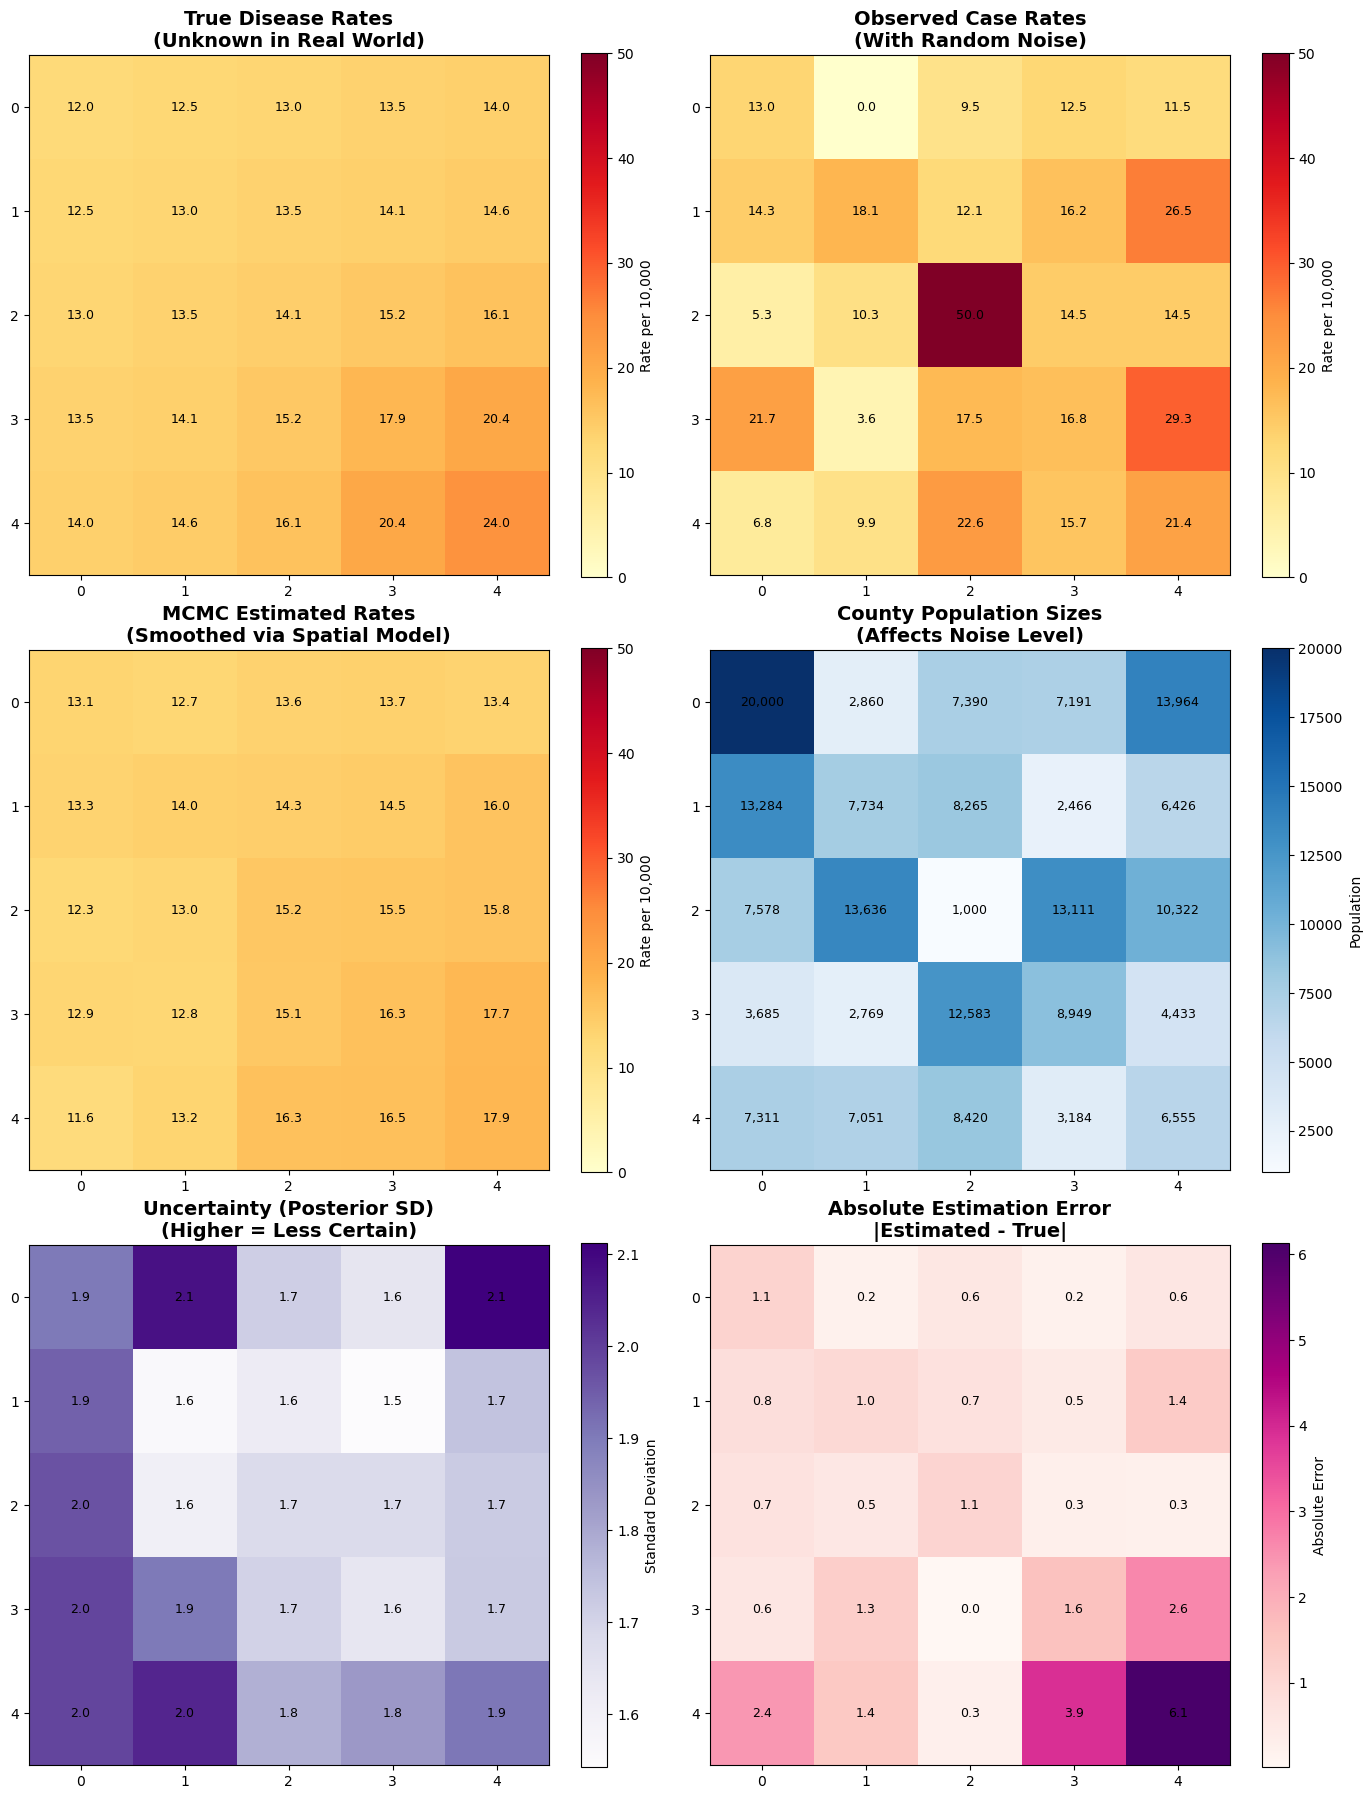

In [100]:
# Main results figure
fig1 = visualize_results(
    observed_rates, true_rates, 
    results['mean'], results['sd'],
    population_sizes
)
plt.show()

## Check MCMC Convergence

Let's examine the convergence for the lower-right county (the disease cluster).

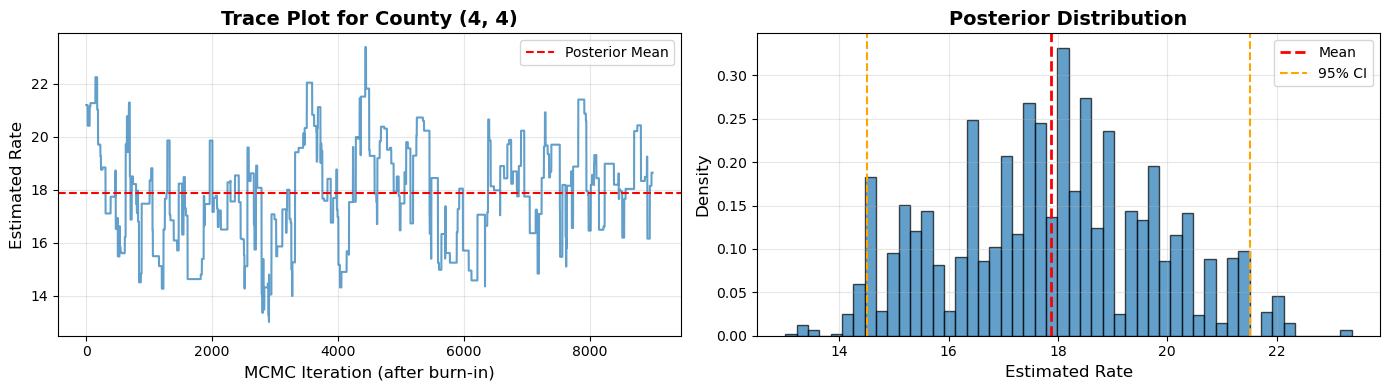

In [101]:
# Convergence diagnostics for the cluster county
fig2 = plot_convergence(samples, i_county=4, j_county=4)
plt.show()

## Compare Different Smoothing Strengths

The tau parameter controls how much neighboring counties influence each other.


--- Running MCMC with tau=1.0 ---
Starting MCMC with 5000 iterations
Proposal SD: 2.0, Spatial tau: 1.0
  Iteration 2000/5000
  Iteration 4000/5000

MCMC complete
Acceptance rate: 35.04%

--- Running MCMC with tau=3.0 ---
Starting MCMC with 5000 iterations
Proposal SD: 2.0, Spatial tau: 3.0
  Iteration 2000/5000
  Iteration 4000/5000

MCMC complete
Acceptance rate: 63.70%

--- Running MCMC with tau=10.0 ---
Starting MCMC with 5000 iterations
Proposal SD: 2.0, Spatial tau: 10.0
  Iteration 2000/5000
  Iteration 4000/5000

MCMC complete
Acceptance rate: 81.48%


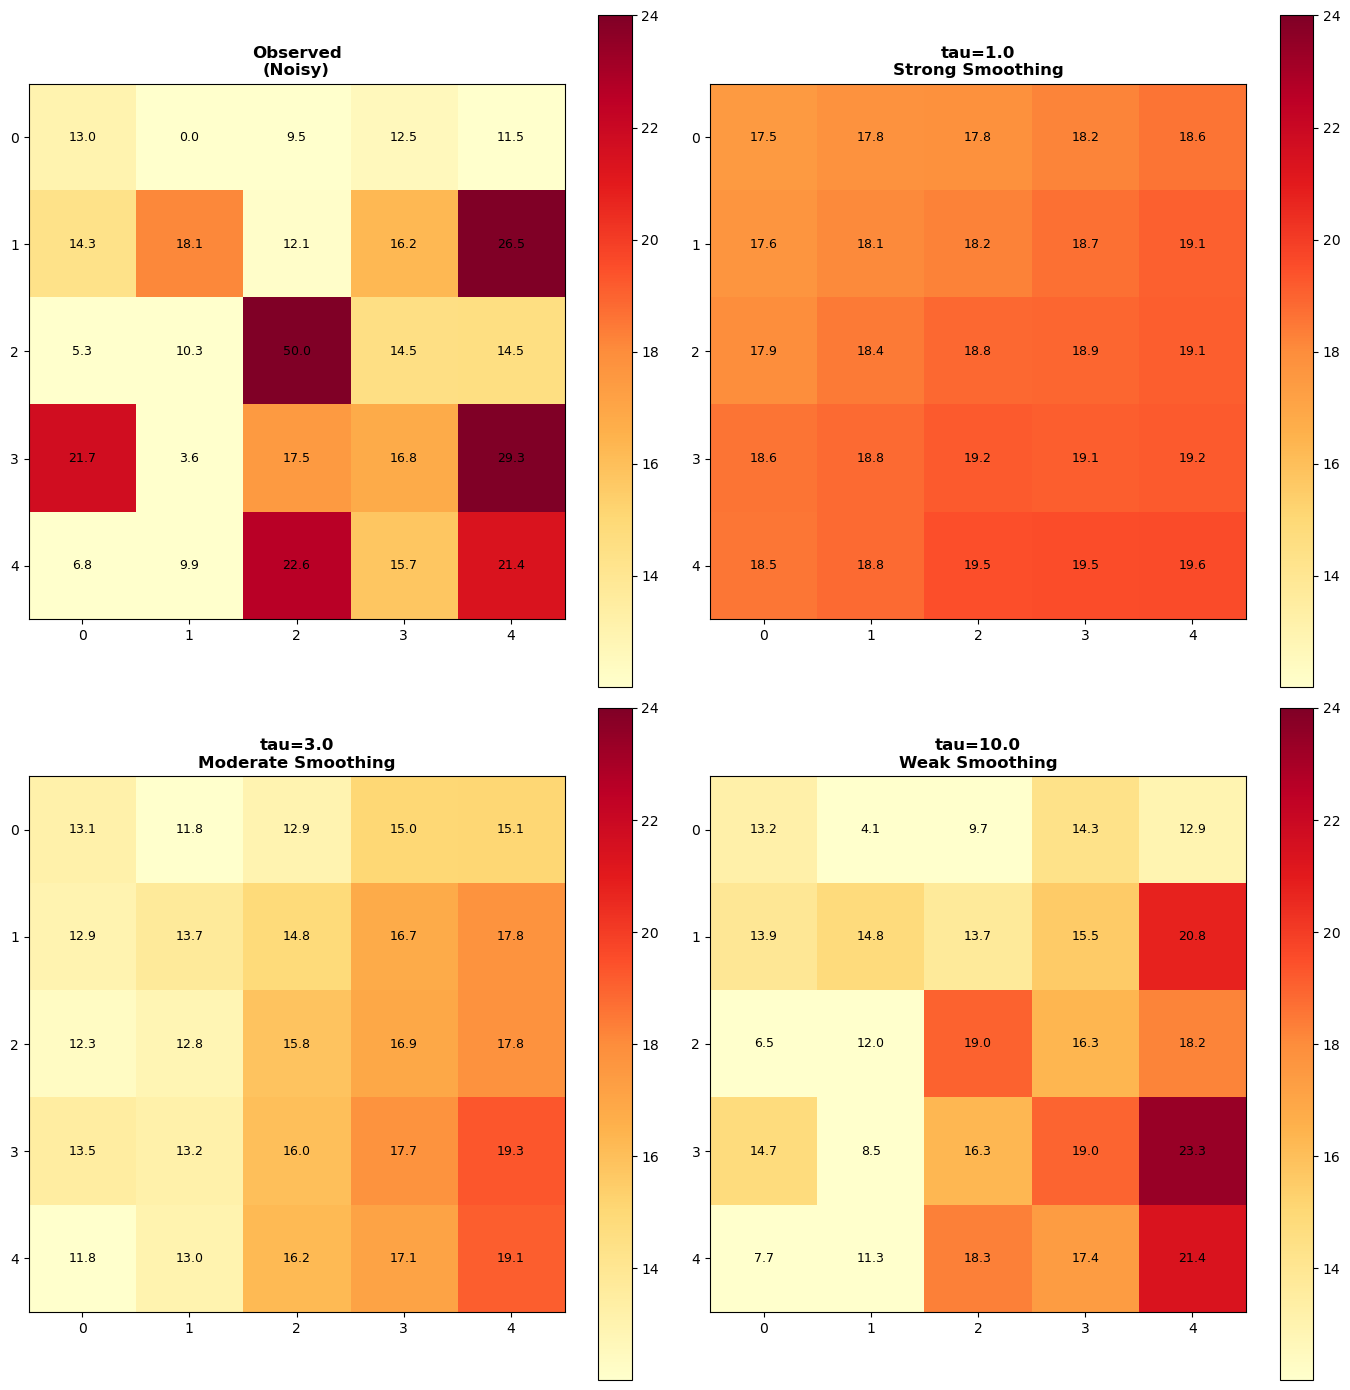

In [102]:
# Compare smoothing levels
fig3 = compare_smoothing_scenarios(observed_rates, population_sizes, true_rates)
plt.show()

## Key Insights

**What We Learned:**
- MCMC smooths random noise while preserving real spatial patterns
- Small counties have more uncertainty (higher posterior SD)
- Spatial correlation helps 'borrow strength' from neighbors
- The tau parameter controls smoothing: lower = smoother estimates
- This method identifies real disease clusters vs. random variation

**Real-World Applications:**
- Cancer cluster detection
- Infectious disease hotspot identification
- Environmental health risk mapping
- Chronic disease surveillance
- Resource allocation for public health interventions
